# Earthquake Analysis

Significant earthquakes (magnitude 6.0+) recorded worldwide between **1995 and 2023**
— 1,000 events, 19 fields each.

This notebook loads the data, sanity-checks it, then works through a set of
visualisations: bar charts, pie charts, a histogram, a scatter plot, a time
series and a box plot.

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

df = pd.read_csv("earthquake.csv")
df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

## 2. Clean and derive

`date_time` arrives as a `DD-MM-YYYY HH:MM` string, so it needs an explicit
format. We also bucket magnitude into bands and pull out the year for later.

In [3]:
df["date_time"] = pd.to_datetime(df["date_time"], format="%d-%m-%Y %H:%M")
df["year"] = df["date_time"].dt.year

magnitude_bins = [6.5, 7.0, 7.5, 8.0, 8.5, 9.5]
magnitude_labels = ["6.5-6.9", "7.0-7.4", "7.5-7.9", "8.0-8.4", "8.5+"]
df["magnitude_band"] = pd.cut(
    df["magnitude"],
    bins=magnitude_bins,
    labels=magnitude_labels,
    right=False,
    include_lowest=True,
)

print("Exact duplicate rows:", df.duplicated().sum())
print("Rows sharing a title + date_time:", df.duplicated(subset=["title", "date_time"], keep=False).sum())
print("Date range:", df["date_time"].min().date(), "to", df["date_time"].max().date())
print("Magnitude range:", df["magnitude"].min(), "to", df["magnitude"].max())

Exact duplicate rows: 0
Rows sharing a title + date_time: 4
Date range: 1995-05-05 to 2023-08-16
Magnitude range: 6.5 to 9.1


In [4]:
# Shared plot styling so every chart below looks consistent
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## 3. Bar chart — how many quakes in each magnitude band

The dataset only contains magnitude 6.0+ events, and the count falls off sharply
as magnitude climbs.

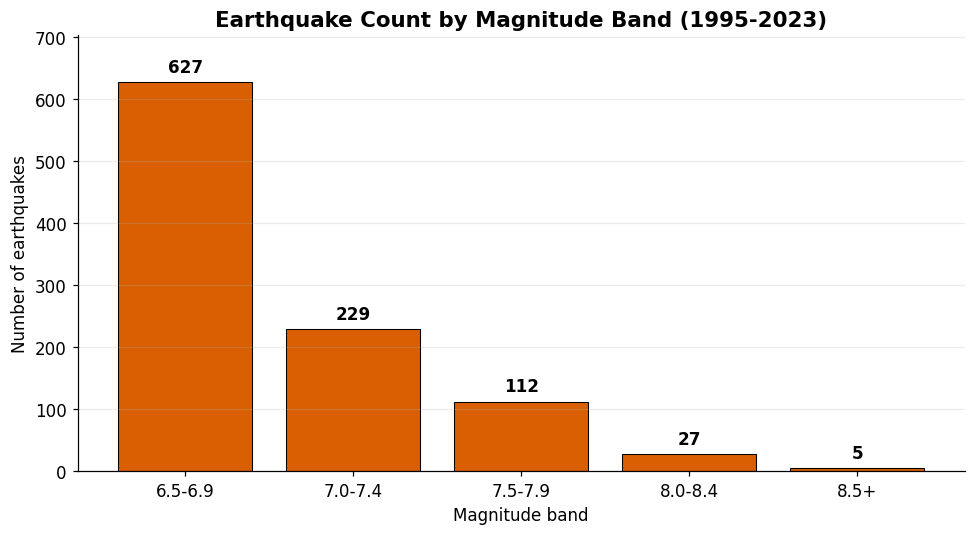

In [5]:
band_counts = df["magnitude_band"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(band_counts.index.astype(str), band_counts.values,
              color="#d95f02", edgecolor="black", linewidth=0.7)
ax.set_title("Earthquake Count by Magnitude Band (1995-2023)")
ax.set_xlabel("Magnitude band")
ax.set_ylabel("Number of earthquakes")
ax.set_ylim(0, band_counts.max() * 1.12)
ax.grid(axis="x", visible=False)
for bar in bars:
    ax.annotate(f"{int(bar.get_height())}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", xytext=(0, 4), textcoords="offset points",
                fontweight="bold")
fig.tight_layout()
plt.show()

## 4. Pie chart — how often a tsunami was flagged

About a third of these events carried a tsunami flag.

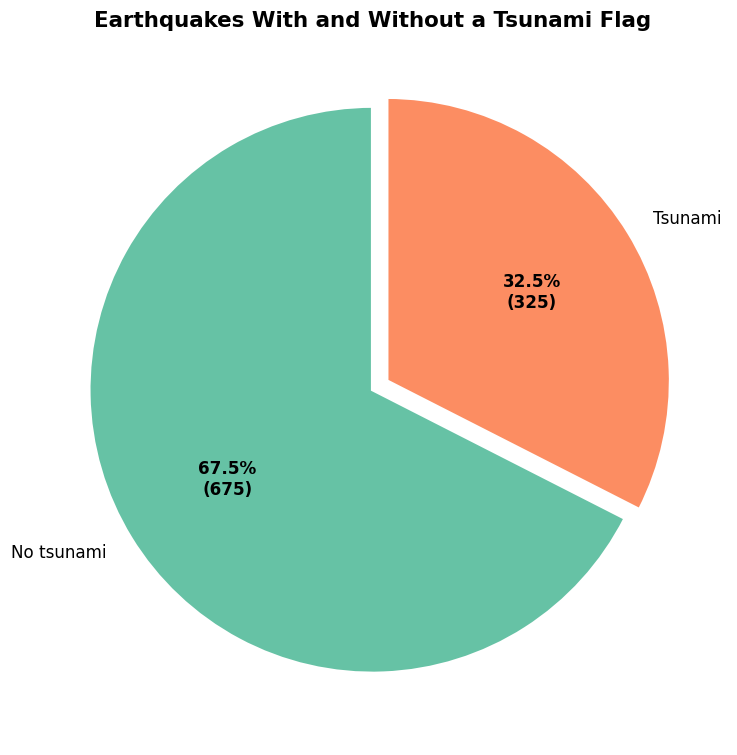

In [6]:
tsunami_counts = df["tsunami"].map({0: "No tsunami", 1: "Tsunami"}).value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    tsunami_counts,
    labels=tsunami_counts.index,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * tsunami_counts.sum() / 100))})",
    startangle=90,
    colors=["#66c2a5", "#fc8d62"],
    explode=(0, 0.06),
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for t in autotexts:
    t.set_fontweight("bold")
ax.set_title("Earthquakes With and Without a Tsunami Flag")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

## 5. Histogram — the shape of the magnitude distribution

A steep right-skew: the vast majority sit near the 6.0 floor, with a thin tail
running out past magnitude 9.

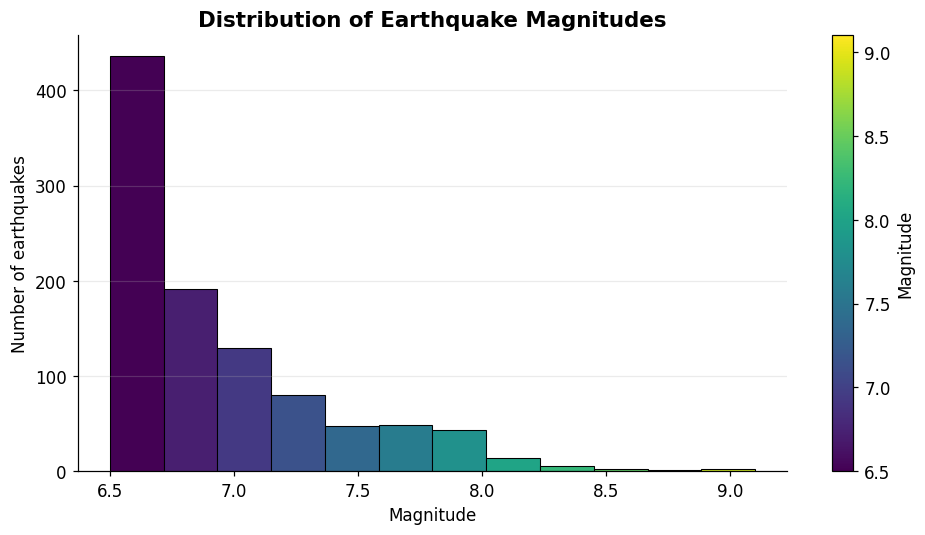

In [7]:
magnitudes = df["magnitude"].dropna()

fig, ax = plt.subplots(figsize=(9, 5))
counts, bins, patches = ax.hist(magnitudes, bins=12, edgecolor="black", linewidth=0.7)

normalizer = mpl.colors.Normalize(vmin=bins[0], vmax=bins[-1])
color_map = mpl.colormaps["viridis"]
for bin_start, patch in zip(bins[:-1], patches):
    patch.set_facecolor(color_map(normalizer(bin_start)))

color_bar = fig.colorbar(mpl.cm.ScalarMappable(norm=normalizer, cmap=color_map), ax=ax)
color_bar.set_label("Magnitude")
ax.set_title("Distribution of Earthquake Magnitudes")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Number of earthquakes")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## 6. Horizontal bar — which countries appear most

`country` is only populated for 651 of the 1,000 rows, so read this as "of the
events we could attribute to a country". Indonesia dominates, which tracks with
its position on the Ring of Fire.

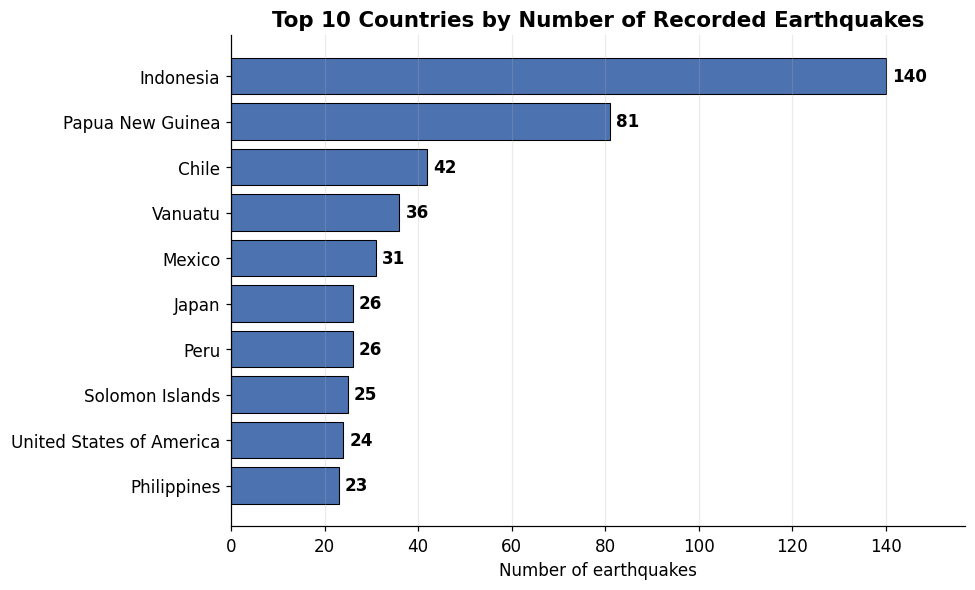

In [8]:
top_countries = df["country"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(top_countries.index, top_countries.values,
               color="#4c72b0", edgecolor="black", linewidth=0.7)
ax.set_title("Top 10 Countries by Number of Recorded Earthquakes")
ax.set_xlabel("Number of earthquakes")
ax.set_xlim(0, top_countries.max() * 1.12)
ax.grid(axis="y", visible=False)
for bar in bars:
    ax.annotate(f"{int(bar.get_width())}",
                (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                va="center", ha="left", xytext=(4, 0), textcoords="offset points",
                fontweight="bold")
fig.tight_layout()
plt.show()

## 7. Pie chart — PAGER alert levels

`alert` is missing for 551 rows, so this covers only the 449 events that were
assigned a level. Green overwhelmingly dominates; red is rare.

Events with an alert level: 449 of 1000


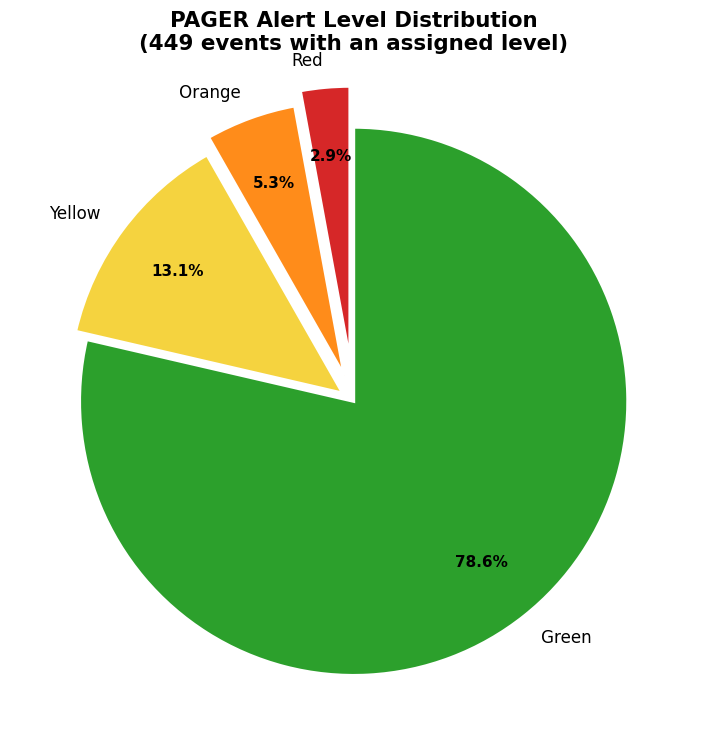

In [9]:
alert_order = ["green", "yellow", "orange", "red"]
alert_colors = {"green": "#2ca02c", "yellow": "#f5d33f", "orange": "#ff8c1a", "red": "#d62728"}
alert_counts = df["alert"].value_counts().reindex(alert_order).dropna()

print(f"Events with an alert level: {int(alert_counts.sum())} of {len(df)}")

fig, ax = plt.subplots(figsize=(7.5, 7))
wedges, texts, autotexts = ax.pie(
    alert_counts,
    labels=[a.capitalize() for a in alert_counts.index],
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    counterclock=False,
    colors=[alert_colors[a] for a in alert_counts.index],
    explode=[0, 0.05, 0.10, 0.15],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75,
)
for t in autotexts:
    t.set_fontweight("bold")
    t.set_fontsize(10)
ax.set_title("PAGER Alert Level Distribution\n(449 events with an assigned level)")
fig.tight_layout()
plt.show()

## 8. Scatter plot — depth against magnitude

Most large events are shallow. Colour encodes `sig`, the significance score,
which rises with both magnitude and felt impact.

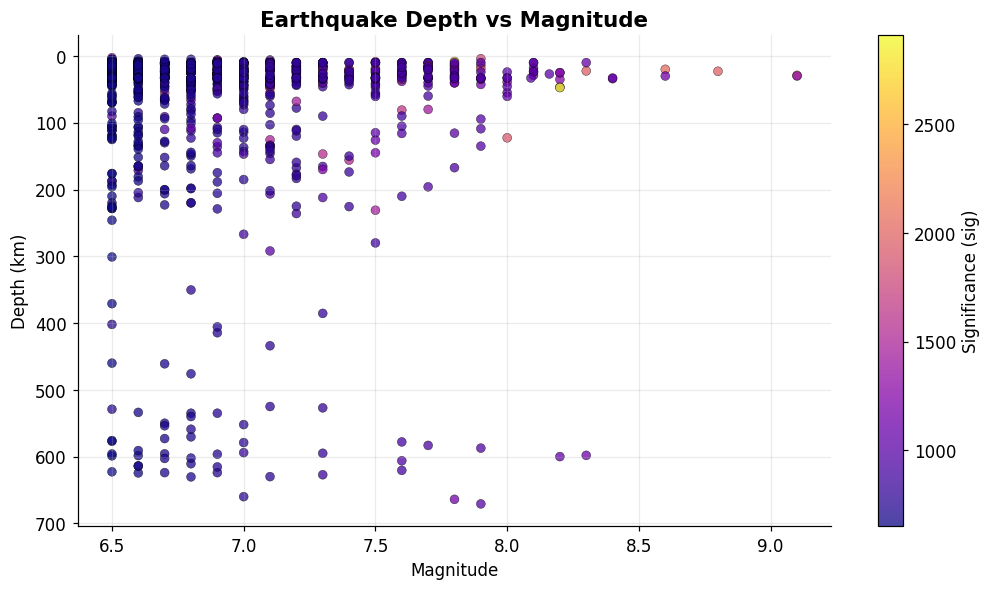

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
scatter = ax.scatter(
    df["magnitude"], df["depth"],
    c=df["sig"], cmap="plasma",
    s=34, alpha=0.75, edgecolor="black", linewidth=0.3,
)
color_bar = fig.colorbar(scatter, ax=ax)
color_bar.set_label("Significance (sig)")
ax.set_title("Earthquake Depth vs Magnitude")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Depth (km)")
ax.invert_yaxis()  # deeper events sit lower on the axis
fig.tight_layout()
plt.show()

## 9. Line chart — events per year

Counts bounce around 25-50 a year with no dramatic trend. Bear in mind this is a
curated 1,000-event sample, so year-to-year movement reflects the sample as much
as real seismic activity.

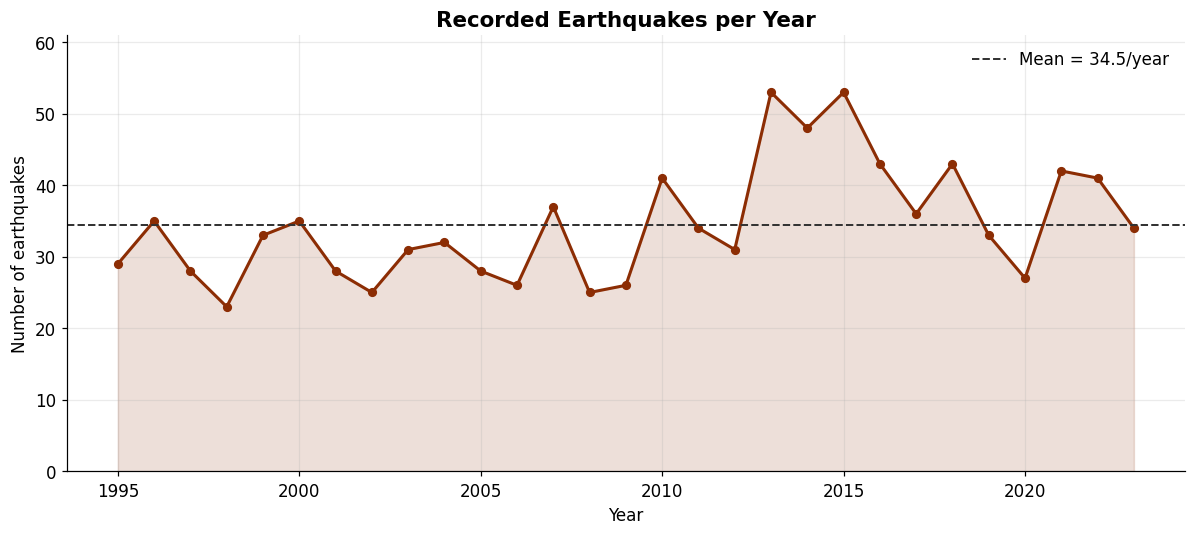

In [11]:
per_year = df.groupby("year").size()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(per_year.index, per_year.values, marker="o", markersize=5,
        linewidth=2, color="#8c2d04")
ax.fill_between(per_year.index, per_year.values, alpha=0.15, color="#8c2d04")
ax.axhline(per_year.mean(), linestyle="--", linewidth=1.3, color="#333",
           label=f"Mean = {per_year.mean():.1f}/year")
ax.set_title("Recorded Earthquakes per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of earthquakes")
ax.set_ylim(0, per_year.max() * 1.15)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 10. Box plot — magnitude by alert level

A useful cross-check: alert level should climb with magnitude, and it does, though
the spread overlaps a lot because PAGER also weighs population exposure.

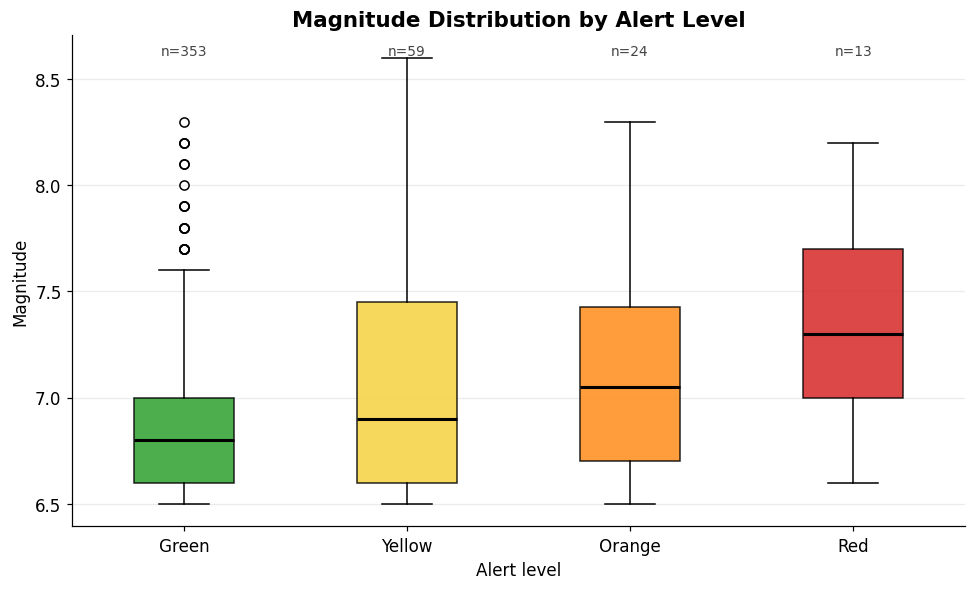

In [12]:
groups = [df.loc[df["alert"] == a, "magnitude"].dropna() for a in alert_order]

fig, ax = plt.subplots(figsize=(9, 5.5))
bp = ax.boxplot(groups, tick_labels=[a.capitalize() for a in alert_order],
                patch_artist=True, medianprops={"color": "black", "linewidth": 2})
for patch, a in zip(bp["boxes"], alert_order):
    patch.set_facecolor(alert_colors[a])
    patch.set_alpha(0.85)
ax.set_title("Magnitude Distribution by Alert Level")
ax.set_xlabel("Alert level")
ax.set_ylabel("Magnitude")
ax.grid(axis="x", visible=False)
for i, g in enumerate(groups, start=1):
    ax.annotate(f"n={len(g)}", (i, ax.get_ylim()[1]), ha="center", va="top",
                xytext=(0, -6), textcoords="offset points", fontsize=9, color="#444")
fig.tight_layout()
plt.show()

## 11. Summary table

The strongest events in the dataset.

In [13]:
(df.nlargest(10, "magnitude")[["title", "magnitude", "depth", "alert", "tsunami", "sig", "year"]]
   .reset_index(drop=True))

,title,magnitude,depth,alert,tsunami,sig,year
0,"M 9.1 - 2011 Great Tohoku Earthquake, Japan",9.1,29.00,NaN,0,2184,2011
1,M 9.1 - 2004 Sumatra - Andaman Islands Earthquake,9.1,30.00,NaN,0,1274,2004
2,"M 8.8 - 36 km WNW of Quirihue, Chile",8.8,22.90,NaN,0,1991,2010
3,M 8.6 - off the west coast of northern Sumatra,8.6,20.00,yellow,0,2048,2012
4,"M 8.6 - 78 km WSW of Singkil, Indonesia",8.6,30.00,NaN,0,1138,2005
5,"M 8.4 - 122 km SW of Bengkulu, Indonesia",8.4,34.00,NaN,0,1086,2007
6,"M 8.4 - 6 km SSW of Atico, Peru",8.4,33.00,NaN,0,1086,2001
7,"M 8.3 - 48 km W of Illapel, Chile",8.3,22.44,orange,1,1960,2015
8,M 8.3 - Sea of Okhotsk,8.3,598.10,green,1,1115,2013
9,M 8.3 - Kuril Islands,8.3,10.00,NaN,0,1064,2006
